In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_column" , None)

In [ ]:
df = pd.read_csv("adult.csv", na_values=['?', ' ?'])

In [213]:
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,NaN,>50K


In [214]:
df.shape

(32561, 15)

In [215]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [216]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

In [217]:
null_count = df.isnull().sum()

null_count = null_count[ null_count>0 ]

pd.DataFrame({
    "Columns" : null_count.index,
    "Null-Count" : null_count.values,
    "Null %" : ((null_count.values / null_count.sum()) * 100).round(2)
}).sort_values("Null-Count" , ascending=False)

,Columns,Null-Count,Null %
1,occupation,1843,43.24
0,workclass,1836,43.08
2,native.country,583,13.68


In [218]:
df.drop(columns=["fnlwgt"] , inplace=True)

In [219]:
df.describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,1077.648844,87.303830,40.437456
std,13.640433,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [220]:
pd.DataFrame({
    "Class" : df["income"].value_counts().index,
    "Count" : df["income"].value_counts().values
}).sort_values("Count" , ascending=False)

,Class,Count
0,<=50K,24720
1,>50K,7841


### Univariate Analysis , Bivariate Analysis , MultiVariate Analysis

In [221]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="str").drop("income" , axis=1).columns

print(f"{num_cols}  \n{cat_cols}")

Index(['age', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')  
Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='str')


In [222]:
df_num = df[num_cols]
df_cat = df[cat_cols]

In [223]:
"""
What are you plotting?
│
├── 1 numeric        → histplot / kdeplot / boxplot
├── 1 categorical    → countplot
├── 2 numeric        → scatterplot / regplot / jointplot
├── 1 num + 1 cat    → boxplot / violinplot / stripplot
├── 2 categorical    → countplot (with hue) / heatmap of crosstab
├── Many numeric     → pairplot / heatmap (correlation)
└── Split by group   → add hue=, col=, or row=
"""
print()

## Numerical Columns Analysis

In [224]:
# Style settings
sns.set_style("whitegrid") # whitegrid, darkgrid, white, dark, ticks
sns.set_context("notebook") # paper, notebook, talk, poster
sns.set_palette("Set2") # Set1, Set2, pastel, deep, muted, viridis

In [225]:

"""
    sns.< PLOT_TYPE>(
    data=df,
    X="<X_COLUMN>",
    y="<Y_COLUMN>", 
    hue="<COLOR_BY>",
    palette="Set2" 

"""

'\n    sns.< PLOT_TYPE>(\n    data=df,\n    X="<X_COLUMN>",\n    y="<Y_COLUMN>", \n    hue="<COLOR_BY>",\n    palette="Set2" \n\n'

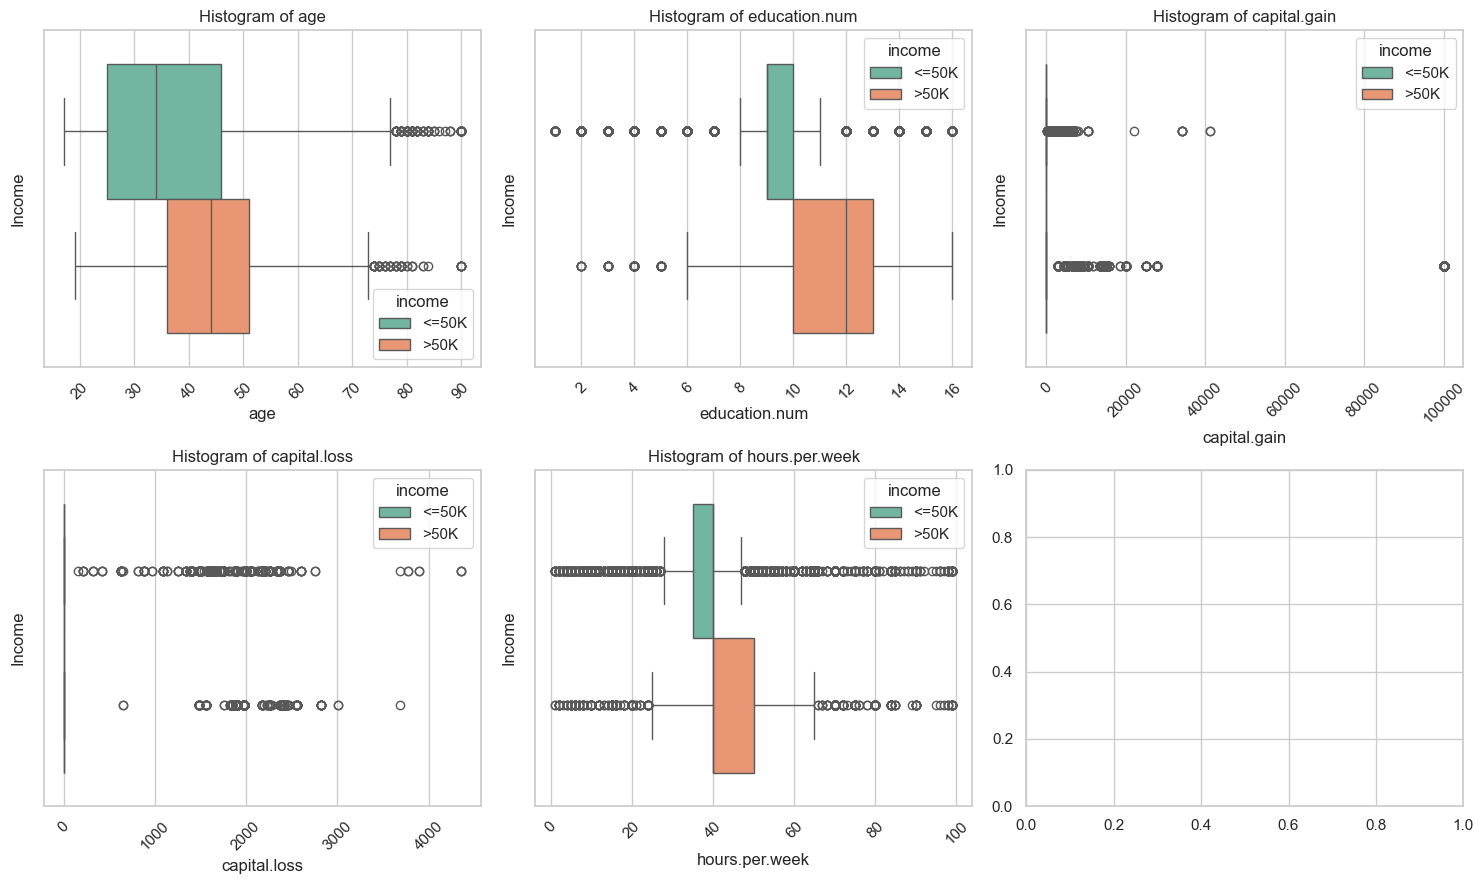

In [226]:
fig , axes = plt.subplots(2 , 3 , figsize=(15 , 9)) 

axes = axes.flatten()

for i , col in enumerate(num_cols):

    sns.boxplot(
        data=df,
        x=col,
        hue="income",
        ax = axes[i]
    )

    axes[i].set_title(f"Histogram of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Income")
    axes[i].tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

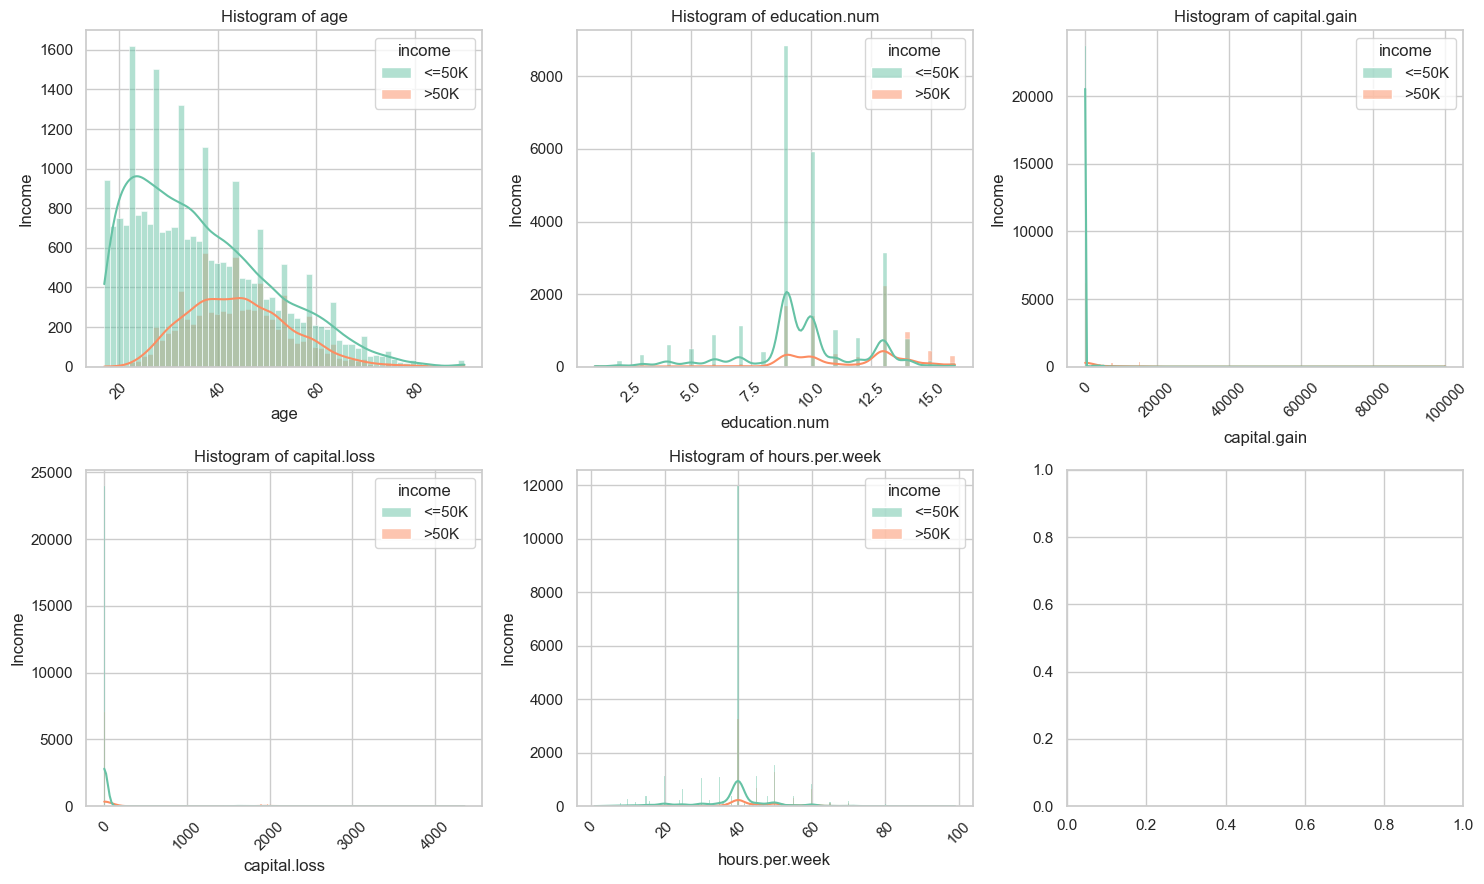

In [227]:
fig , axes = plt.subplots(2 , 3 , figsize=(15 , 9)) 

axes = axes.flatten()

for i , col in enumerate(num_cols):

    sns.histplot(
        data=df,
        x=col,
        hue="income",
        kde=True,
        ax = axes[i]
    )

    axes[i].set_title(f"Histogram of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Income")
    axes[i].tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

## Categorical Column Analysis

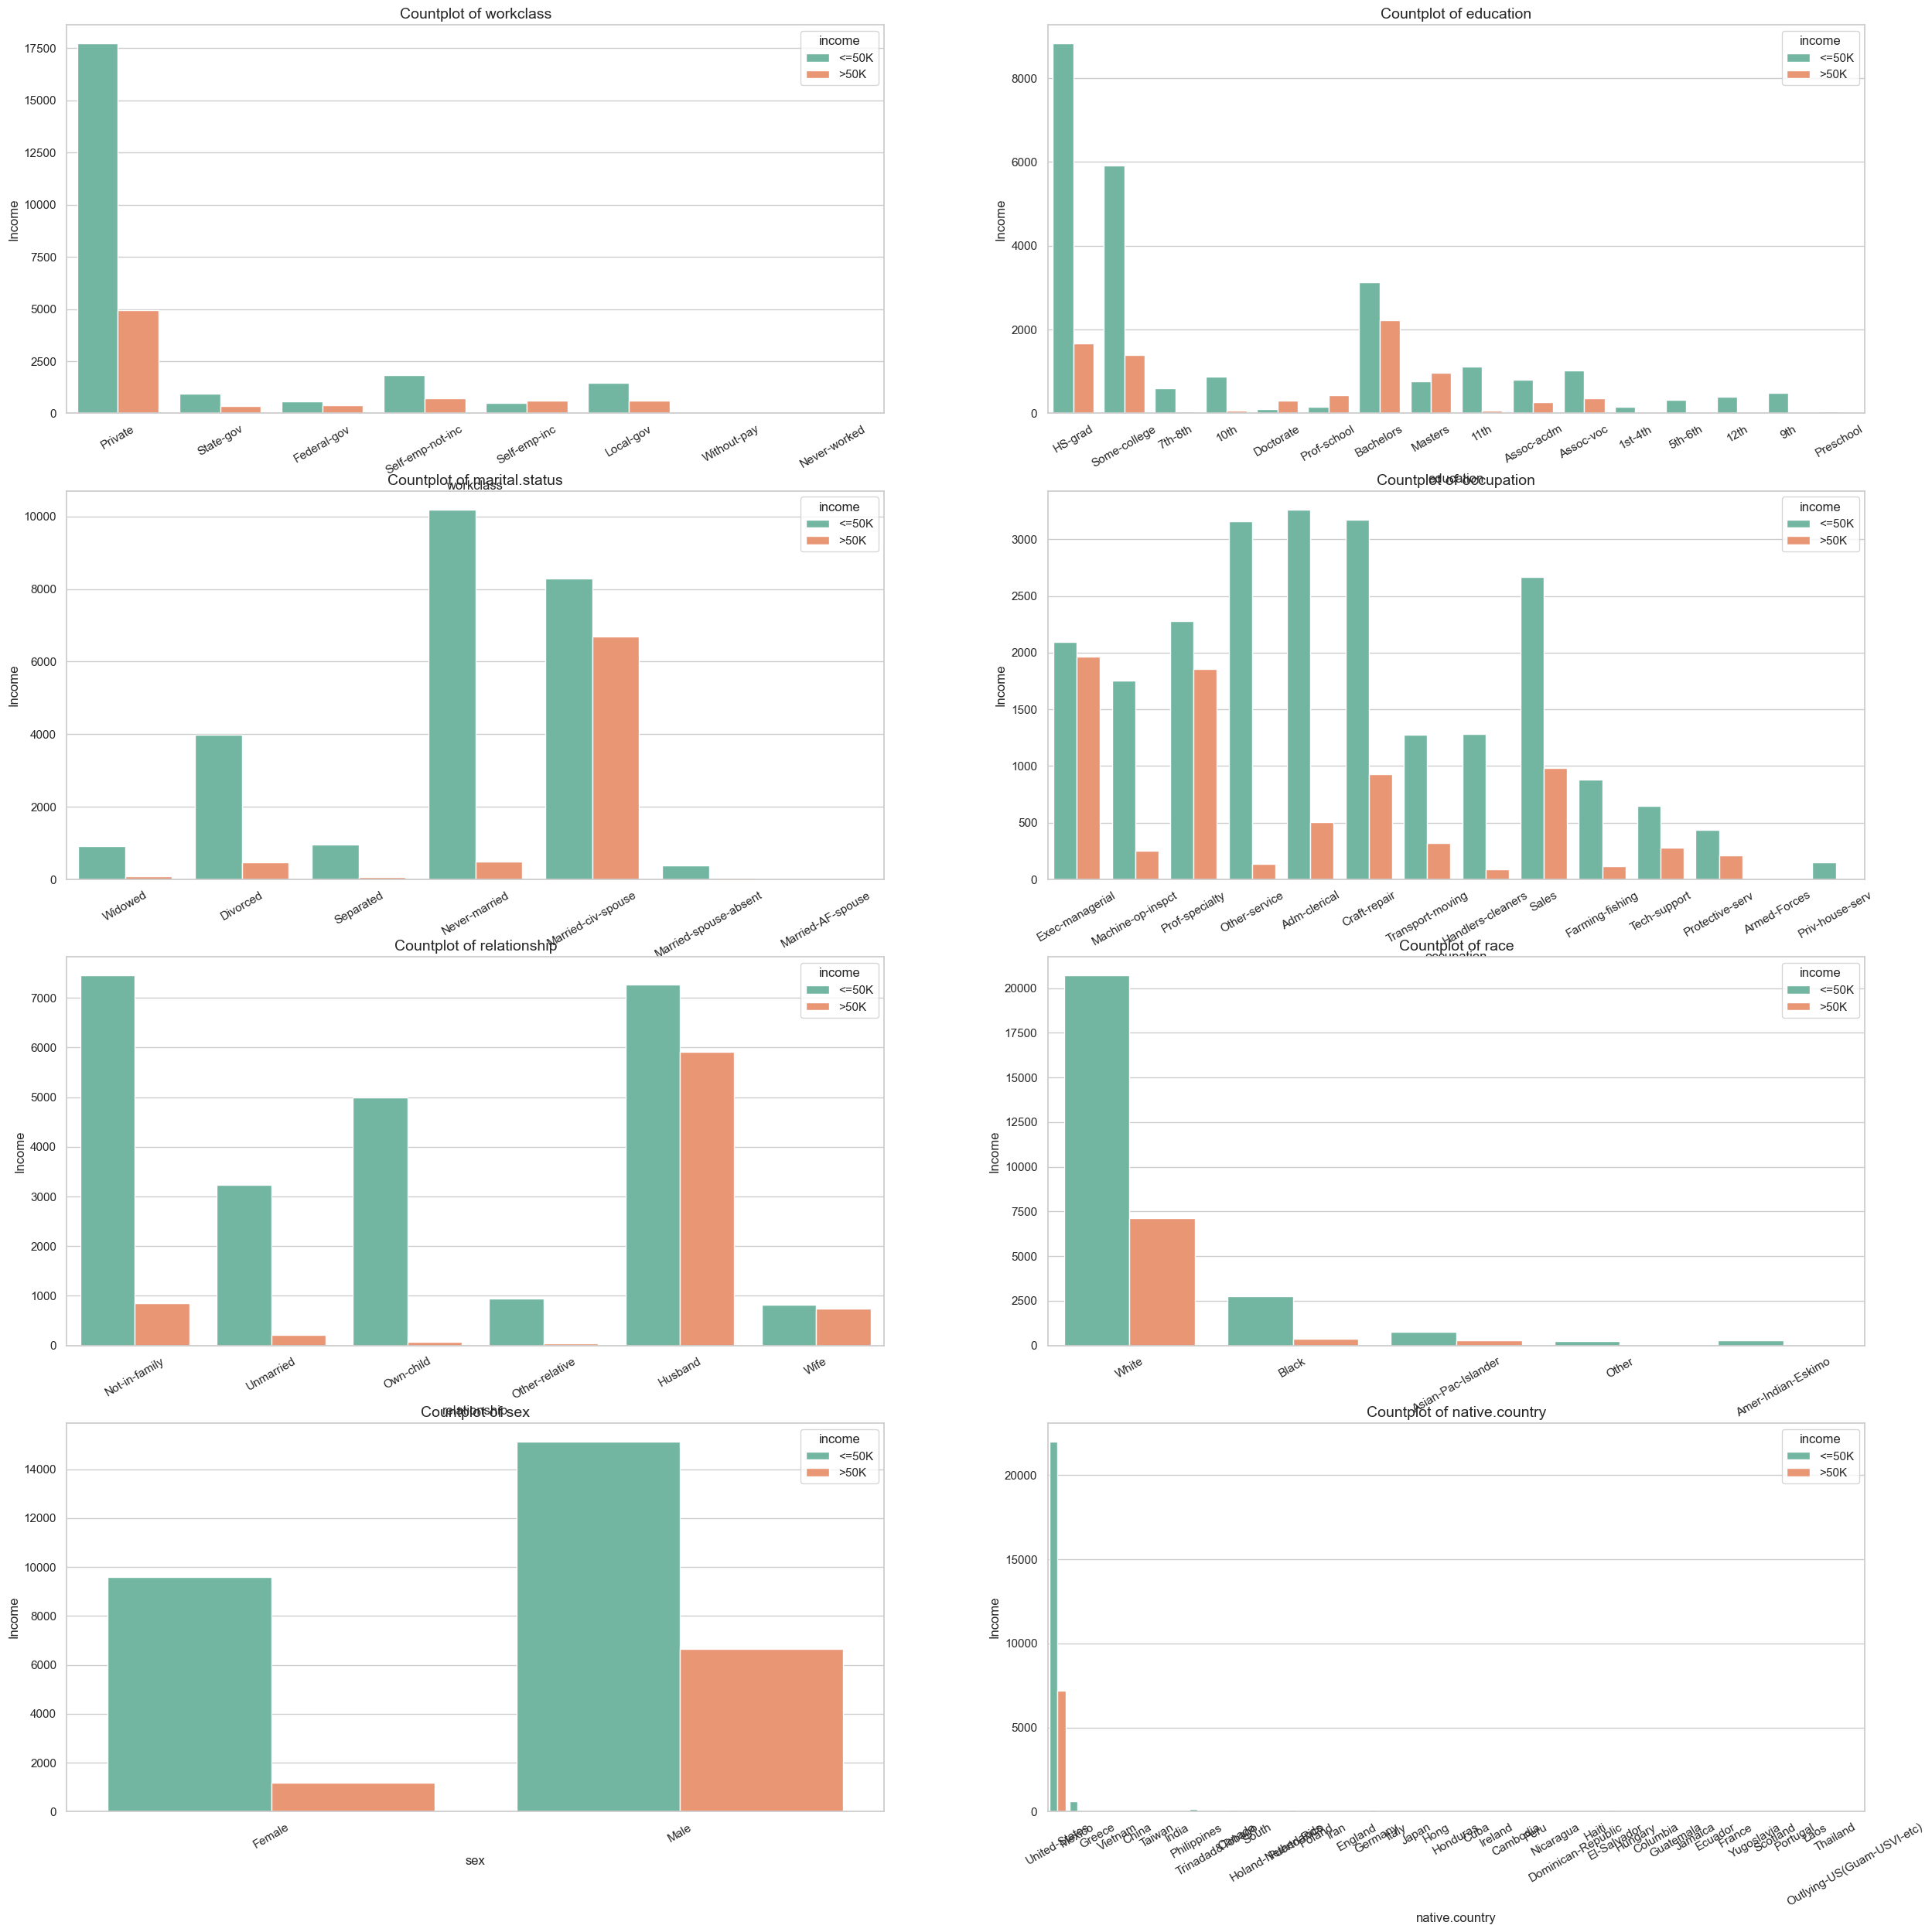

In [228]:


fig , axes = plt.subplots( 4 , 2 , figsize=(30 , 30) )

axes = axes.flatten()

for i , col in enumerate(cat_cols):

    sns.countplot(
        data = df,
        x = col,
        ax = axes[i],
        hue="income"
    )

    axes[i].set_title(f"Countplot of {col}" , fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Income")
    axes[i].tick_params(axis="x", labelrotation=30)

In [229]:
len(cat_cols)

8

### Heatmap based upon Correlation Coefficient

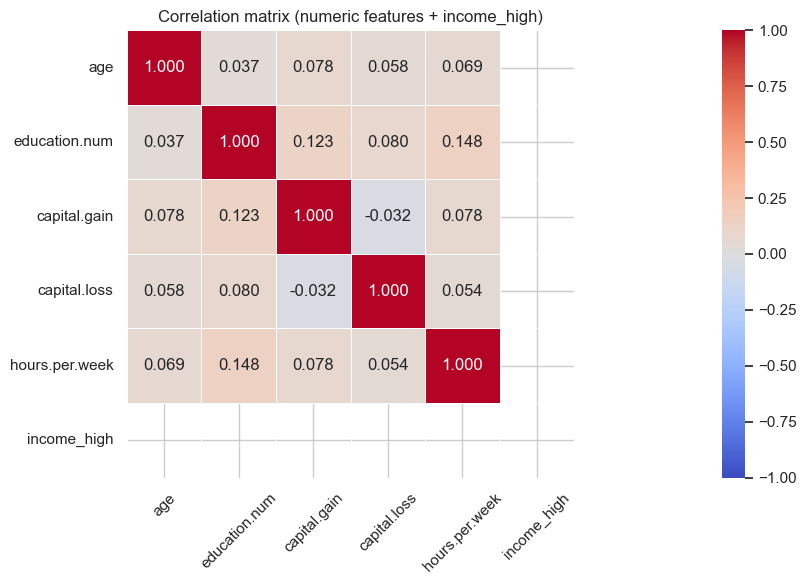

In [230]:
df_corr = df.copy()

df_corr["income_high"] = (df_corr["income"] == ">50k").astype(int)

corr = df_corr[list(num_cols) + ["income_high"]].corr().round(3)

plt.figure(figsize=(30,6))

sns.heatmap(
    corr ,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidth=0.5,
    fmt=".3f",
    square=True
)

plt.title("Correlation matrix (numeric features + income_high)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Drop Null Values

In [231]:
print(f"Shape of dataset before dropping null values : {df.shape}")
df.dropna(inplace=True)
print(f"Shape of dataset after dropping null values : {df.shape}")

Shape of dataset before dropping null values : (32561, 14)
Shape of dataset after dropping null values : (30162, 14)


### Encode Target variable
-    **if income >50k => 1**
-   **if income <=50k => 0**

In [232]:

df["income"] = df["income"].apply(lambda x : 1 if x==">50K" else 0)


"""

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder([ "<=50k" , ">50k" ])
df["income"] = le.fit_transform()

"""

np.int64(7508)

### One-Hot-Encoding Categorical Columns

In [233]:
print(f"shape of dataset before Encoding : {df.shape}")
df_encoded = pd.get_dummies(
    df, 
    columns=cat_cols, 
    drop_first=True,
)
print(f"shape of dataset after Encoding : {df_encoded.shape}")


shape of dataset before Encoding : (30162, 14)
shape of dataset after Encoding : (30162, 96)


In [234]:
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns

In [235]:
for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(int)

In [236]:
non_numeric_cols = df_encoded.select_dtypes(exclude = np.number).columns
print(f"number of Non-Numeric Columns is {len(non_numeric_cols)}")

number of Non-Numeric Columns is 0


### Scaling Dataset

In [237]:
"""
def train_test_split(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.2,
    random_state=None
):

    np.random.seed(random_state)

    n = X.shape[0]
    test_n = int(np.ceil(n * test_size))

    indices = np.random.permutation(n)

    test_indices = indices[:test_n]
    train_indices = indices[test_n:]

    X_train = X.iloc[train_indices]
    X_test = X.iloc[test_indices]

    y_train = y.iloc[train_indices]
    y_test = y.iloc[test_indices]

    return X_train, X_test , y_train, y_test

"""

'\ndef train_test_split(\n    X: pd.DataFrame,\n    y: pd.Series,\n    test_size: float = 0.2,\n    random_state=None\n):\n\n    np.random.seed(random_state)\n\n    n = X.shape[0]\n    test_n = int(np.ceil(n * test_size))\n\n    indices = np.random.permutation(n)\n\n    test_indices = indices[:test_n]\n    train_indices = indices[test_n:]\n\n    X_train = X.iloc[train_indices]\n    X_test = X.iloc[test_indices]\n\n    y_train = y.iloc[train_indices]\n    y_test = y.iloc[test_indices]\n\n    return X_train, X_test , y_train, y_test\n\n'

In [238]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("income" , axis=1)
y = df_encoded["income"]

X_train , X_test , y_train , y_test = train_test_split(
    X , y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

In [239]:
print(f"X_train shape: {X_train.shape} , y_train shape : {y_train.shape}")
print(f"X_test shape: {X_test.shape} , y_test shape : {y_test.shape}")


X_train shape: (24129, 95) , y_train shape : (24129,)
X_test shape: (6033, 95) , y_test shape : (6033,)


In [240]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print(f"Before Scaling X_train Descriptive Statistics: \n{X_train[num_cols].describe()}")

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


print(f"\nAfter Scaling X_train Descriptive Statistics: \n{X_train[num_cols].describe()}")


Before Scaling X_train Descriptive Statistics: 
                age  education.num  capital.gain  capital.loss  hours.per.week
count  24129.000000   24129.000000  24129.000000  24129.000000    24129.000000
mean      38.494260      10.130383   1120.294293     87.468440       40.976460
std       13.165991       2.543845   7592.010771    402.265222       11.988826
min       17.000000       1.000000      0.000000      0.000000        1.000000
25%       28.000000       9.000000      0.000000      0.000000       40.000000
50%       37.000000      10.000000      0.000000      0.000000       40.000000
75%       47.000000      13.000000      0.000000      0.000000       45.000000
max       90.000000      16.000000  99999.000000   4356.000000       99.000000

After Scaling X_train Descriptive Statistics: 
                age  education.num  capital.gain  capital.loss  hours.per.week
count  2.412900e+04   2.412900e+04  2.412900e+04  2.412900e+04    2.412900e+04
mean  -2.327838e-16  -2.556057e-16 

## Model Training

### Simple Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000 , random_state=42)

lr.fit(X_train , y_train)

y_pred = lr.predict(X_test)

### Model Evaluation

In [251]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score ,
    precision_score , f1_score,
    roc_curve , roc_auc_score , 
    precision_recall_curve ,
)


y_true = y_test
y_pred = y_pred

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# Individual Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

# ROC-AUC
y_prob = lr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

print("ROC-AUC  :", auc)

# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(
    y_true,
    y_prob
)


Confusion Matrix:
 [[4221  310]
 [ 576  926]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4531
           1       0.75      0.62      0.68      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.77      0.79      6033
weighted avg       0.85      0.85      0.85      6033

Accuracy : 0.8531410575169899
Recall   : 0.6165113182423435
Precision: 0.7491909385113269
F1 Score : 0.6764061358655953
ROC-AUC  : 0.9128436417154087


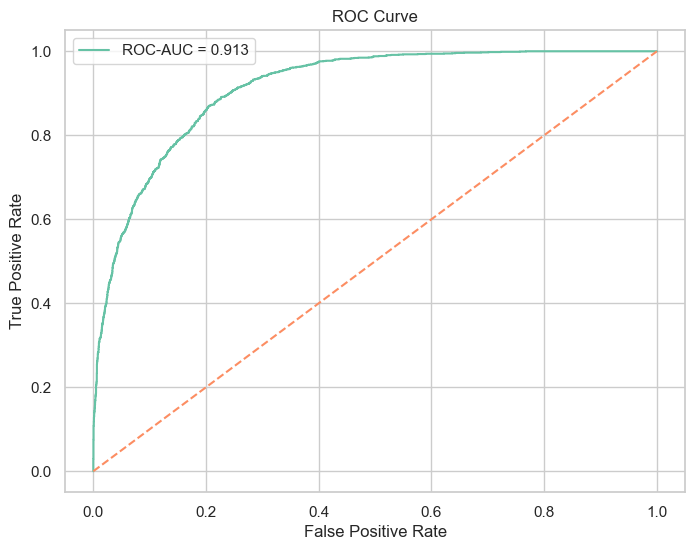

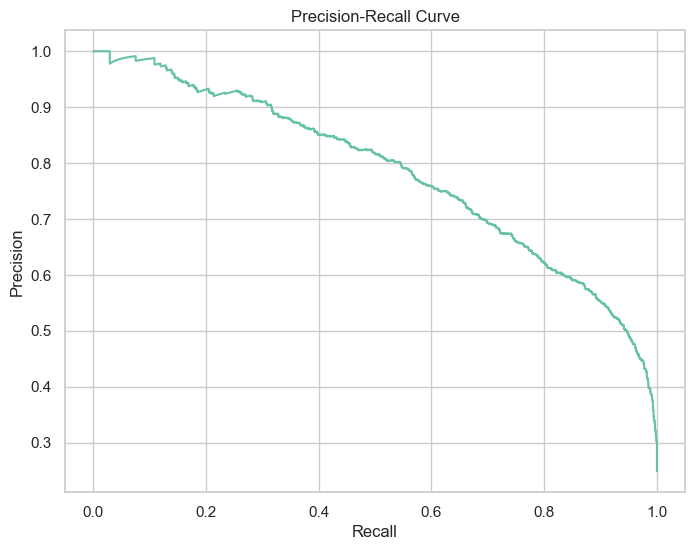

In [252]:
import matplotlib.pyplot as plt

# ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# Precision-Recall Curve
plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()